In [2]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

In [3]:
G_ctrl = nx.read_gml('/home/share/huadjyin/home/zhangkexin2/code/meta_index/experiment/results/network/12.18/crc.ctrl.test.pretrain.pooling.cosine.bootstrap.0.1.gml')
G_case = nx.read_gml('/home/share/huadjyin/home/zhangkexin2/code/meta_index/experiment/results/network/12.18/crc.case.test.pretrain.pooling.cosine.bootstrap.0.1.gml')





In [4]:
crc_biomarker = pd.read_csv('/home/share/huadjyin/home/zhangkexin2/code/meta_index/experiment/results/features/11.25/sort.multidisease.mean/CRC.biomarker.txt', sep='\t', header=None)
crc_biomarker.columns = ['taxa', 'weight']
crc_biomarker['weight.abs'] = crc_biomarker['weight'].abs()


原始数据行数: 858
绝对值列 weight.abs 统计:
  均值: 0.0168
  标准差: 0.0323
  95%置信区间阈值: 0.0577
  筛选后行数: 43
  筛选比例: 5.0%


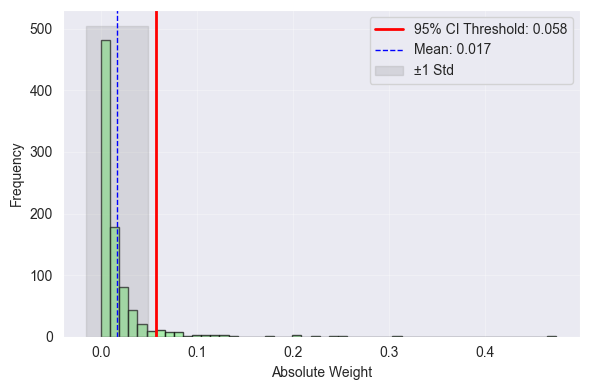

In [5]:

def filter(df, confidence=0.95, filter_below=True):
    
    # 2. 计算95%置信区间阈值
    abs_values = df['weight.abs'].dropna()  # 移除缺失值
    mean_val = abs_values.mean()
    std_val = abs_values.std()
    
    threshold = df['weight.abs'].quantile(0.95)
    filtered_df = df[df['weight.abs'] >= threshold]
    
    # 打印统计信息
    print(f"原始数据行数: {len(df)}")
    print(f"绝对值列 weight.abs 统计:")
    print(f"  均值: {mean_val:.4f}")
    print(f"  标准差: {std_val:.4f}")
    print(f"  95%置信区间阈值: {threshold:.4f}")
    print(f"  筛选后行数: {len(filtered_df)}")
    print(f"  筛选比例: {len(filtered_df)/len(df):.1%}")
    
    return threshold, filtered_df


    
    # 使用函数：计算相关系数的绝对值，并基于95%置信区间筛选
threshold, filtered_df = filter(
        crc_biomarker, 
        confidence=0.95,
        filter_below=True  # 保留绝对值较小的（较弱的）相关性
    )


    
fig, axes = plt.subplots(1, 1, figsize=(6, 4))

# 子图2：绝对值分布及阈值
abs_values = crc_biomarker['weight.abs']
axes.hist(abs_values, bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
axes.axvline(x=threshold, color='red', linestyle='-', linewidth=2, 
                label=f'95% CI Threshold: {threshold:.3f}')
axes.axvline(x=abs_values.mean(), color='blue', linestyle='--', linewidth=1, 
                label=f'Mean: {abs_values.mean():.3f}')
axes.fill_betweenx([0, axes.get_ylim()[1]], 
                      abs_values.mean() - abs_values.std(), 
                      abs_values.mean() + abs_values.std(), 
                      alpha=0.2, color='gray', label='±1 Std')
axes.set_xlabel('Absolute Weight')
axes.set_ylabel('Frequency')
# axes[1].set_title('Absolute Correlation Distribution with Threshold')
axes.legend()
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
def extract_edges_connected_to_targets(G, target_nodes):
    """
    提取图中所有与 target_nodes 相连的边组成的子图。
    参数：
    - G: nx.Graph 或 nx.DiGraph
    - target_nodes: list，目标节点
    返回：
    - subG: 包含这些边的子图
    """
    edges = []
    for u in target_nodes:
        if u not in G:
            continue
        for v in G.neighbors(u):
            edges.append((u, v)) if not isinstance(G, nx.DiGraph) else edges.append((u, v))
    return G.edge_subgraph(edges).copy()


In [7]:
filtered_df.sort_values(by=['weight.abs'], ascending=False, inplace=True)

/tmp/ipykernel_4039026/960190226.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df.sort_values(by=['weight.abs'], ascending=False, inplace=True)


In [8]:
crc_biomarker_list = list(filtered_df['taxa'])

G_biomarker_case = extract_edges_connected_to_targets(G_case, crc_biomarker_list)
G_biomarker_ctrl = extract_edges_connected_to_targets(G_ctrl, crc_biomarker_list)

nx.write_gml(G_biomarker_case, '/home/share/huadjyin/home/zhangkexin2/code/meta_index/experiment/results/network/12.18/crc.case.biomarker.test.pretrain.pooling.cosine.bootstrap.0.1.gml')
nx.write_gml(G_biomarker_ctrl, '/home/share/huadjyin/home/zhangkexin2/code/meta_index/experiment/results/network/12.18/crc.ctrl.biomarker.test.pretrain.pooling.cosine.bootstrap.0.1.gml')

filtered_df.to_csv('/home/share/huadjyin/home/zhangkexin2/code/meta_index/experiment/results/network/12.18/crc.biomarker.filtered.txt', sep='\t')

# 对case ctrl群体网络美观，加一些属性，比如边流行率

In [16]:
import pandas as pd
import numpy as np
import networkx as nx
import pickle

In [17]:

def rename_func(old_name):
    # 取第2位开始到结束 (Python 索引从0开始，故第2位是 index 1)
    name_cut = old_name[2:]
    
    name = name_cut.replace('-', ' ')
    parts = name.split(maxsplit=1)

    # 如果字符串确实包含两部分（属名 + 种名）
    if len(parts) == 2:
        # parts[0][0].upper() 提取第一个单词的首字母并大写
        # parts[1] 是剩下的所有内容
        return f"{parts[0][0].upper()}. {parts[1]}"
        
    return name

def extract_and_annotate_subgraph(G, target_nodes, crc_good_biomarker, crc_bad_biomarker):
    """
    提取诱导子图，添加好/坏菌属性，并按规则重命名节点。
    """
    # 1. 过滤并提取诱导子图
    valid_nodes = [n for n in target_nodes if n in G]
    subG = G.subgraph(valid_nodes).copy()
    
    # 2. 添加属性 (Biomarker_Type)
    attrs = {}
    for node in subG.nodes():
        if node in crc_good_biomarker:
            status = 'Beneficial Biomarker'
        elif node in crc_bad_biomarker:
            status = 'Pathogenic Biomarker'
        else:
            status = 'Unknown'
        attrs[node] = {'type': status}
    
    nx.set_node_attributes(subG, attrs)
    


    # 4. 执行重命名
    # copy=False 因为我们已经在之前 copy 过了
    subG = nx.relabel_nodes(subG, rename_func, copy=False)
    subG.remove_nodes_from(list(nx.isolates(subG)))
    
    return subG

def contrust_graph(corr_matrix, threshold):
    G = nx.Graph()
    for i in range(len(corr_matrix)):
        for j in range(i + 1, len(corr_matrix)):
            corr_value = corr_matrix.iloc[i, j]
            if abs(corr_value) > threshold:
                node1 = corr_matrix.index[i]
                node2 = corr_matrix.columns[j]
                G.add_edge(node1, node2, weight=corr_value)
    # G = G.subgraph([n for n in G.nodes() if G.degree[n] >= 3])
    return G

In [30]:
case_corr_matrix = pd.read_csv('/bgi-seq-model-2/codes/zhangkexin/meta_index/experiment/results/network/1.8/ibd/ibd.pretrain.case.edge.cv.4.9.csv', index_col=0)
ctrl_corr_matrix = pd.read_csv('/bgi-seq-model-2/codes/zhangkexin/meta_index/experiment/results/network/1.8/ibd/ibd.pretrain.ctrl.edge.cv.4.9.csv', index_col=0)
case_graph = contrust_graph(case_corr_matrix, 0.01)
ctrl_graph = contrust_graph(ctrl_corr_matrix, 0.01)

crc_biomarker = pd.read_csv('/bgi-seq-model-2/codes/zhangkexin/meta_index/experiment/results/features/11.25/sort.multidisease.mean/IBD.biomarker.txt', sep='\t', header=None)
crc_biomarker['weight.abs'] = crc_biomarker[1].abs()
crc_biomarker = crc_biomarker.sort_values('weight.abs', ascending=False)
# top_biomarker = list(crc_biomarker[:30][0])
# crc_good_biomarker = list(crc_biomarker.iloc[:30][crc_biomarker.iloc[:30][1] < 0][0])
crc_good_biomarker = list(crc_biomarker[crc_biomarker[1] < 0].iloc[:30, 0])
crc_bad_biomarker = list(crc_biomarker[crc_biomarker[1] > 0].iloc[:30, 0])
top_biomarker = crc_bad_biomarker+crc_good_biomarker

case_biomarker_graph = extract_and_annotate_subgraph(case_graph, top_biomarker, crc_good_biomarker, crc_bad_biomarker)
ctrl_biomarker_graph = extract_and_annotate_subgraph(ctrl_graph, top_biomarker, crc_good_biomarker, crc_bad_biomarker)

In [31]:
# 样本 → individual_network 索引
dir='/bgi-seq-model-2/codes/zhangkexin/meta_index/experiment/results/network/1.8/ibd/'
# crc_profile = pd.read_csv(dir+'crc.all.profile.clean.csv', index_col=0)
crc_profile = pd.read_csv(dir+'ibd.all.profile.no.clean.csv', index_col=0)
crc_profile.columns=[rename_func(i) for i in crc_profile.columns]
sample_list = list(crc_profile.index)

label_df = pd.read_csv(
    '/bgi-seq-model-2/datasets/zhangkexin/meta_index/metaphlan4/fine-tune/curated_LiS_CRC_20204_v0908.train_test.phe',
    sep='\t', index_col=0)
case_samples = []
ctrl_samples = []
for i in sample_list:
    if label_df.loc[i, 'disease_united'] == 'IBD':
        case_samples.append(i)
    elif label_df.loc[i, 'disease_united'] == 'healthy':
        ctrl_samples.append(i)


individual_network = np.load(dir+'ibd.pretrain.emb.individual.npy')
taxa2id = pickle.load(open(dir+'ibd.pretrain.emb.individual.index.pkl','rb'))
taxa2id = {rename_func(k): v for k, v in taxa2id.items()}

In [32]:
sample2idx = {s: i for i, s in enumerate(sample_list)}
case_idx = [sample2idx[s] for s in case_samples if s in sample2idx]
ctrl_idx = [sample2idx[s] for s in ctrl_samples if s in sample2idx]

case_n = len(case_idx)
ctrl_n = len(ctrl_idx)

In [21]:
def edge_prevalence(ind_net, sample_indices, i, j):
    if len(sample_indices) == 0:
        return np.nan

    sub = ind_net[sample_indices, i, j]

    # 统计不是 NaN 的个数
    present = np.sum(~np.isnan(sub))

    return present / len(sample_indices)


In [22]:
def add_edge_prev(G, ind_net, sample_indices, taxa2id):
    for u, v in G.edges():
        i = taxa2id[u]
        j = taxa2id[v]

        prev = edge_prevalence(ind_net, sample_indices, i, j)
        G.edges[u, v]['prev'] = prev


In [33]:
add_edge_prev(case_biomarker_graph, individual_network, case_idx, taxa2id)
add_edge_prev(ctrl_biomarker_graph, individual_network, ctrl_idx, taxa2id)

In [24]:
def node_prevalence(crc_profile, samples, taxon):
    valid_samples = [s for s in samples if s in crc_profile.index]
    if len(valid_samples) == 0:
        return np.nan

    values = crc_profile.loc[valid_samples, taxon]
    return (values > 0).sum() / len(valid_samples)


In [25]:
def add_node_prev(G, crc_profile, samples):
    for node in G.nodes():
        prev = node_prevalence(crc_profile, samples, node)
        G.nodes[node]['node_prev'] = prev


In [34]:
add_node_prev(case_biomarker_graph, crc_profile, case_samples)
add_node_prev(ctrl_biomarker_graph, crc_profile, ctrl_samples)

In [27]:
def annotate_case_ctrl_networks(case_graph, ctrl_graph):

    # ========= 1️⃣ 边 =========
    case_edges = {frozenset(e) for e in case_graph.edges()}
    ctrl_edges = {frozenset(e) for e in ctrl_graph.edges()}

    shared_edges = case_edges & ctrl_edges

    # case_graph 边属性
    for u, v in case_graph.edges():
        key = frozenset((u, v))
        case_graph.edges[u, v]['origin'] = 'shared' if key in shared_edges else 'only'

    # ctrl_graph 边属性
    for u, v in ctrl_graph.edges():
        key = frozenset((u, v))
        ctrl_graph.edges[u, v]['origin'] = 'shared' if key in shared_edges else 'only'


    # ========= 2️⃣ 节点 =========
    case_nodes = set(case_graph.nodes())
    ctrl_nodes = set(ctrl_graph.nodes())

    shared_nodes = case_nodes & ctrl_nodes

    # case_graph 节点属性
    for n in case_graph.nodes():
        case_graph.nodes[n]['origin'] = 'shared' if n in shared_nodes else 'only'

    # ctrl_graph 节点属性
    for n in ctrl_graph.nodes():
        ctrl_graph.nodes[n]['origin'] = 'shared' if n in shared_nodes else 'only'


annotate_case_ctrl_networks(case_biomarker_graph, ctrl_biomarker_graph)

In [35]:
def add_node_size_by_rank(G, good_list, bad_list):
    """
    根据 biomarker 在 good/bad 列表中的排名，为图中节点添加 rank 和 node_size 属性
    """
    attrs = {}
    
    # 处理 Good Biomarker (Beneficial)
    for index, old_name in enumerate(good_list):
        new_name = rename_func(old_name)
        rank = index + 1  # 排名从 1 开始
        # 设定一个大小计算规则：排名越靠前，size 越大。
        # 比如：第一名 size=50，第三十名 size=21
        size = 50 - rank + 1  
        
        # 只为当前图中存在的节点添加属性
        if new_name in G.nodes():
            attrs[new_name] = {'biomarker_rank': rank, 'node_weight': size}
            
    # 处理 Bad Biomarker (Pathogenic)
    for index, old_name in enumerate(bad_list):
        new_name = rename_func(old_name)
        rank = index + 1
        size = 50 - rank + 1
        
        if new_name in G.nodes():
            attrs[new_name] = {'biomarker_rank': rank, 'node_weight': size}
            
    # 批量将属性写入图中
    nx.set_node_attributes(G, attrs)

# ==========================================
# 在调用 nx.write_gml 之前，执行以下两行：
# ==========================================
add_node_size_by_rank(case_biomarker_graph, crc_good_biomarker, crc_bad_biomarker)
add_node_size_by_rank(ctrl_biomarker_graph, crc_good_biomarker, crc_bad_biomarker)

In [36]:
nx.write_gml(case_biomarker_graph, '/bgi-seq-model-2/codes/zhangkexin/meta_index/experiment/results/network/1.8/network.case.ctrl/ibd.pretrain.case.2biomarker.IG.0.01.4.9.gml',stringizer=str)
nx.write_gml(ctrl_biomarker_graph, '/bgi-seq-model-2/codes/zhangkexin/meta_index/experiment/results/network/1.8/network.case.ctrl/ibd.pretrain.ctrl.2biomarker.IG.0.01.4.9.gml',stringizer=str)